# Modelo de Hopfield: memoria asociativa mediante el método Monte Carlo


Simulación de una red neuronal de Hopfield con el algoritmo de Metropolis, estudiando su capacidad de recuperar patrones almacenados en función de la temperatura y del número de memorias.

## Metodología de simulación y herramientas computacionales

Para llevar a cabo la simulación numérica del modelo de Hopfield se ha trabajado en un ordenador personal con sistema operativo **Windows 11**, sobre el que se ha instalado, a través del gestor de paquetes **Chocolatey**, la versión **Python 3.14.3**, lo que permite un control preciso de las dependencias del proyecto y garantiza la reproducibilidad de la ejecución. El coste computacional moderado del problema hace innecesario recurrir a un entorno de altas prestaciones: el equipo empleado, con procesador **Intel Core i3 de dos núcleos**, resuelve la totalidad del trabajo —que abarca redes de hasta 40×40 = 1600 neuronas, la recuperación de patrones, un barrido completo en temperatura y el estudio de la capacidad de almacenamiento, todos ellos con promedios sobre varias realizaciones independientes— en un tiempo total de cómputo de aproximadamente **cinco minutos**.

En el plano del desarrollo, se ha utilizado inteligencia artificial generativa como herramienta de apoyo a la programación y a la estructuración del trabajo, actuando como un **motor de metaprogramación** que ayuda a transformar el planteamiento físico del problema en una implementación computacional eficiente. En este caso se ha recurrido únicamente al modelo **Claude**, que ha intervenido tanto en la elaboración del código como en el análisis de sus errores e ineficiencias, proponiendo mejoras sucesivas hasta alcanzar la implementación definitiva.

A nivel conceptual, la IA ha actuado como un **orquestador semántico**, interpretando el problema físico y guiando la elección de los métodos de simulación más apropiados. El núcleo de la simulación es el **algoritmo de Metropolis**, en el que el movimiento elemental de Monte Carlo consiste en invertir el estado de una única neurona elegida al azar (de disparo a reposo o viceversa), aceptándose el cambio con probabilidad $\min(1,\,e^{-\Delta H/T})$. A diferencia del modelo de Ising clásico, la red es **totalmente conectada** y sus pesos sinápticos se construyen mediante la **regla de aprendizaje de Hebb** a partir de los patrones que se desean almacenar, de modo que cada patrón se convierte en un mínimo de la energía y, por tanto, en un atractor de la dinámica. Sobre esta base se han incorporado varias técnicas propias de la simulación estadística para garantizar resultados fiables: la **reformulación eficiente del cambio de energía** $\Delta H$ en términos de las proyecciones del estado sobre los patrones, que evita construir y recorrer la matriz de pesos completa (de $N^4$ elementos) y reduce el coste de cada paso Monte Carlo de orden $N^4$ a orden $N^2 P$; el uso del **solapamiento** con cada patrón como parámetro de orden para cuantificar la recuperación de la memoria; la preparación de **distintas configuraciones iniciales** (el propio patrón deformado o ruido completamente aleatorio) para estudiar las cuencas de atracción; el **promedio sobre varias realizaciones independientes** con distintas semillas del generador de números aleatorios, para reducir el ruido estadístico y estimar las barras de error; y, en el estudio de la capacidad, el muestreo sobre **conjuntos de patrones aleatorios** independientes para caracterizar la transición a la fase de pérdida de memoria.

En la capa de ejecución, el aspecto computacional más relevante es el uso de la librería **Numba**, un compilador *just-in-time* (JIT) que traduce las funciones críticas de Python a código máquina optimizado a través de la infraestructura de compilación **LLVM**. Mediante el decorador `@njit`, los bucles internos de Monte Carlo —que implican del orden de $10^8$ intentos de cambio de neurona a lo largo de todo el trabajo— se ejecutan sin la sobrecarga del intérprete de Python, lo que reduce drásticamente el tiempo de cómputo y hace viable el muestreo con promedios sobre múltiples realizaciones. No obstante, conviene precisar que la aceleración del cálculo proviene fundamentalmente de la compilación JIT y **no de una paralelización explícita** del código, de modo que los bucles de Monte Carlo se ejecutan como código compilado esencialmente en serie. El resto de la implementación se apoya en las librerías estándar del ecosistema científico de Python: **NumPy** para el cálculo numérico y el manejo eficiente de las matrices de neuronas y de patrones, y **Matplotlib** para la representación gráfica de los resultados y de las configuraciones de la red.

En conjunto, el uso de inteligencia artificial generativa no sustituye en ningún caso el análisis físico ni la comprensión de los métodos de Monte Carlo empleados, sino que introduce una capa de asistencia y metaprogramación que permite organizar el desarrollo, reducir errores de implementación, optimizar el rendimiento del código y conectar de forma más directa la formulación estadística del modelo de Hopfield con su implementación computacional.

## 1. Introducción

El Modelo de Hopfield es un modelo de red neuronal recurrente capaz de funcionar como una **memoria asociativa**: una red que, a partir de una entrada incompleta o corrupta, reconstruye uno de los patrones que tiene almacenados. El modelo es una variante del **modelo de Ising** de la mecánica estadística y, de hecho, puede simularse con el mismo **algoritmo de Metropolis** empleado en la parte obligatoria de la práctica.

La idea física es la siguiente. Igual que en el Ising, se considera una red cuadrada de $N\times N$ nodos con condiciones de contorno periódicas. Ahora cada nodo $(i,j)$ representa una **neurona** que puede estar *disparando* ($s_{i,j}=1$) o *en reposo* ($s_{i,j}=0$). Hay dos diferencias esenciales con el Ising:

1. **Interacciones de largo alcance.** En lugar de acoplarse solo a sus vecinos próximos, cada neurona se conecta con **todas** las demás (red totalmente conectada).
2. **Pesos sinápticos aprendidos.** Las interacciones $\omega_{ij,kl}$ (los *pesos sinápticos*) no son constantes, sino que se construyen mediante la **regla de aprendizaje de Hebb** a partir de un conjunto de $P$ configuraciones prefijadas $\xi^\mu$ —los *patrones* o *memorias*— de modo que cada patrón sea un mínimo de la energía.

Los patrones almacenados se convierten así en **atractores** de la dinámica: el estado de la red evoluciona descendiendo en energía hacia el mínimo más cercano, que es uno de los patrones. Esto es lo que da a la red su capacidad de "recordar".

En este trabajo se estudia el comportamiento emergente de la red en función de la temperatura $T$ y del número de patrones almacenados $P$. Se abordan las cuatro tareas del enunciado:

1. Recuperación de **un único patrón** a temperatura muy baja, partiendo de una condición inicial aleatoria y del patrón deformado, midiendo el **solapamiento** con el patrón en función del tiempo.
2. **Curva de solapamiento frente a la temperatura**, que revela una transición de fase análoga a la magnetización del Ising.
3. Recuperación con **varios patrones** almacenados simultáneamente.
4. Estudio de la **capacidad** de la red: cómo decae la memoria al aumentar $P$ y estimación de la fracción máxima $\alpha_c=P_c/N^2$ de patrones almacenables.

## 2. Implementación del modelo y código

### 2.1 Hamiltoniano, pesos sinápticos y umbral

La energía de una configuración $\mathbf{s}=\{s_{i,j}\}$ viene dada por el hamiltoniano

$$H(\mathbf{s}) = -\frac{1}{2}\sum_{i,j}\sum_{k,l}\omega_{ij,kl}\,s_{i,j}\,s_{k,l} \;+\; \sum_{i,j}\theta_{i,j}\,s_{i,j}.$$

Los pesos sinápticos se construyen con la regla de Hebb a partir de los $P$ patrones $\xi^\mu=\{\xi^\mu_{i,j}\}$, con $\xi^\mu_{i,j}\in\{0,1\}$:

$$\omega_{ij,kl} = \frac{1}{N^2}\sum_{\mu=1}^{P}\bigl(\xi^\mu_{i,j}-a^\mu\bigr)\bigl(\xi^\mu_{k,l}-a^\mu\bigr)\quad\text{si }(i,j)\neq(k,l),\qquad \omega_{ij,ij}=0,$$

donde $a^\mu=\frac{1}{N^2}\sum_{i,j}\xi^\mu_{i,j}$ es la actividad media del patrón $\mu$ (no se permiten autoconexiones). El umbral de disparo se define en términos de los pesos, $\theta_{i,j}=\tfrac{1}{2}\sum_{k,l}\omega_{ij,kl}$. Usando que $\sum_{k,l}(\xi^\mu_{k,l}-a^\mu)=0$ por definición de $a^\mu$, se reduce a una expresión cerrada e **independiente del tiempo**, que se calcula una sola vez:

$$\theta_{i,j}=-\frac{1}{2N^2}\sum_{\mu}\bigl(\xi^\mu_{i,j}-a^\mu\bigr)^2.$$

### 2.2 Dinámica de Metropolis

Se emplea el mismo método Monte Carlo que en el modelo de Ising. Un **paso Monte Carlo** consiste en $N^2$ intentos de cambio. En cada intento:

1. Se elige una neurona $(n,m)$ al azar.
2. Se calcula el cambio de energía $\Delta H$ que supondría invertir su estado, $s_{n,m}\to 1-s_{n,m}$.
3. Se acepta el cambio con probabilidad $p=\min\!\bigl(1,\,e^{-\Delta H/T}\bigr)$.

### 2.3 Cálculo eficiente de $\Delta H$

Calcular $\Delta H$ a partir del hamiltoniano completo sería inviable: la matriz de pesos tiene $N^4$ elementos y recalcular la energía costaría $\mathcal{O}(N^4)$ por intento. Siguiendo el consejo del enunciado, se expresa $\Delta H$ de forma inteligente. Definiendo el **campo local** $h_{n,m}=\sum_{k,l}\omega_{nm,kl}\,s_{k,l}$, un cálculo directo da

$$\Delta H = (1-2\,s_{n,m})\,\bigl(\theta_{n,m}-h_{n,m}\bigr).$$

El truco clave es **no almacenar nunca la matriz de pesos completa**, sino las $P$ *proyecciones* del estado sobre los patrones,

$$R^\mu = \sum_{k,l}\bigl(\xi^\mu_{k,l}-a^\mu\bigr)\,s_{k,l},$$

en términos de las cuales el campo local es

$$h_{n,m} = \frac{1}{N^2}\sum_{\mu}\bigl(\xi^\mu_{n,m}-a^\mu\bigr)\Bigl(R^\mu-\bigl(\xi^\mu_{n,m}-a^\mu\bigr)s_{n,m}\Bigr).$$

Al aceptar un cambio, las proyecciones se actualizan de forma **incremental** en $\mathcal{O}(P)$:

$$R^\mu \longrightarrow R^\mu + \bigl(\xi^\mu_{n,m}-a^\mu\bigr)\,(1-2s_{n,m}).$$

Así el coste de un paso Monte Carlo pasa de $\mathcal{O}(N^4)$ a $\mathcal{O}(N^2 P)$, lo que hace la simulación viable. La parte crítica está compilada con **Numba** (`@njit`), igual que en la simulación de Ising.

### 2.4 Solapamiento

La magnitud que cuantifica cuánto se parece el estado de la red al patrón $\mu$ es el **solapamiento**:

$$m^\mu(\mathbf{s}) = \frac{1}{N^2 a^\mu(1-a^\mu)}\sum_{i,j}\bigl(\xi^\mu_{i,j}-a^\mu\bigr)\bigl(s_{i,j}-a^\mu\bigr) = \frac{R^\mu}{N^2 a^\mu(1-a^\mu)}.$$

Está acotado en $[-1,1]$: vale $+1$ cuando la red reproduce exactamente el patrón ($s_{i,j}=\xi^\mu_{i,j}$) y $-1$ cuando reproduce el *antipatrón* ($s_{i,j}=1-\xi^\mu_{i,j}$), que es otro mínimo del hamiltoniano (un estado espurio).

### 2.5 Estructura del código

El código se organiza en dos módulos reutilizables y un script por tarea:

- **`hopfield.py`** — núcleo de la simulación: construcción de patrones centrados, umbrales y la dinámica de Metropolis compilada con Numba.
- **`patrones.py`** — generación de patrones: aleatorios, deformados, de texto (dígitos/letras) y símbolos balanceados.
- **`tarea1`…`tarea4`** — un script ejecutable por apartado.

El corazón del método es el bucle de Metropolis (extracto de `hopfield.py`), donde se aprecia el uso de las proyecciones `R` y su actualización incremental:

```python
for _ in range(N2):                  # un paso Monte Carlo = N^2 intentos
    n = np.random.randint(N)
    m = np.random.randint(N)
    s_nm = estado[n, m]

    campo = 0.0                       # campo local h_{nm}, coste O(P)
    for mu in range(P):
        e = eta[mu, n, m]
        campo += e * (R[mu] - e * s_nm)
    campo /= N2

    ds = 1 - 2 * s_nm                 # +1 si s=0 ; -1 si s=1
    dH = ds * (theta[n, m] - campo)

    if dH <= 0.0 or np.random.random() < np.exp(-dH / T):
        for mu in range(P):
            R[mu] += eta[mu, n, m] * ds   # actualizacion incremental O(P)
        estado[n, m] = 1 - s_nm
```

In [1]:
# Configuracion e importacion de los modulos del proyecto
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import hopfield as hop      # nucleo de la simulacion (Metropolis + Numba)
import patrones as pat      # generacion de patrones

### 2.6 Validación de las fórmulas

Antes de usar la versión optimizada, comprobamos que la expresión de $\Delta H$ mediante las proyecciones coincide con el cálculo directo (por fuerza bruta) usando la matriz de pesos completa. El error debe ser del orden de la precisión de máquina.

In [2]:
# Comprobacion: Delta H optimizado vs calculo directo con la matriz de pesos completa
rng = np.random.default_rng(0)
N, P = 6, 3
xi = (rng.random((P, N, N)) < 0.5).astype(float)
a = xi.mean(axis=(1, 2))
eta = xi - a[:, None, None]

# matriz de pesos completa (referencia, O(N^4))
w = np.zeros((N, N, N, N))
for i in range(N):
    for j in range(N):
        for k in range(N):
            for l in range(N):
                if (i, j) != (k, l):
                    w[i, j, k, l] = np.sum(eta[:, i, j] * eta[:, k, l]) / N**2
theta = 0.5 * w.sum(axis=(2, 3))

def H(s):
    return -0.5 * np.einsum('ijkl,ij,kl->', w, s, s) + np.sum(theta * s)

s = (rng.random((N, N)) < 0.5).astype(int)
R = np.einsum('mij,ij->m', eta, s)

errores = []
for (n, m) in [(0, 0), (2, 3), (5, 5), (1, 4)]:
    s2 = s.copy(); s2[n, m] = 1 - s2[n, m]
    dH_bruto = H(s2) - H(s)
    campo = np.sum(eta[:, n, m] * (R - eta[:, n, m] * s[n, m])) / N**2
    dH_formula = (1 - 2 * s[n, m]) * (theta[n, m] - campo)
    errores.append(abs(dH_bruto - dH_formula))

print(f"max |Delta H_bruto - Delta H_formula| = {max(errores):.2e}")

max |Delta H_bruto - Delta H_formula| = 1.11e-16


## 3. Resultados

Cada apartado ejecuta el script correspondiente (`ejecutar()` devuelve la figura y muestra por pantalla los valores numéricos relevantes).

### 3.1 Tarea 1 — Recuperación de un único patrón

Se almacena un solo patrón (la letra «A») en una red de $N=30$ ($900$ neuronas) y, a $T=10^{-4}$, se observa su recuperación partiendo de **(i)** el patrón deformado al 30% y **(ii)** una condición inicial aleatoria, midiendo el solapamiento en función del tiempo.

Solapamiento final (inicio aleatorio):  +1.0000
Solapamiento final (patron deformado):  +1.0000


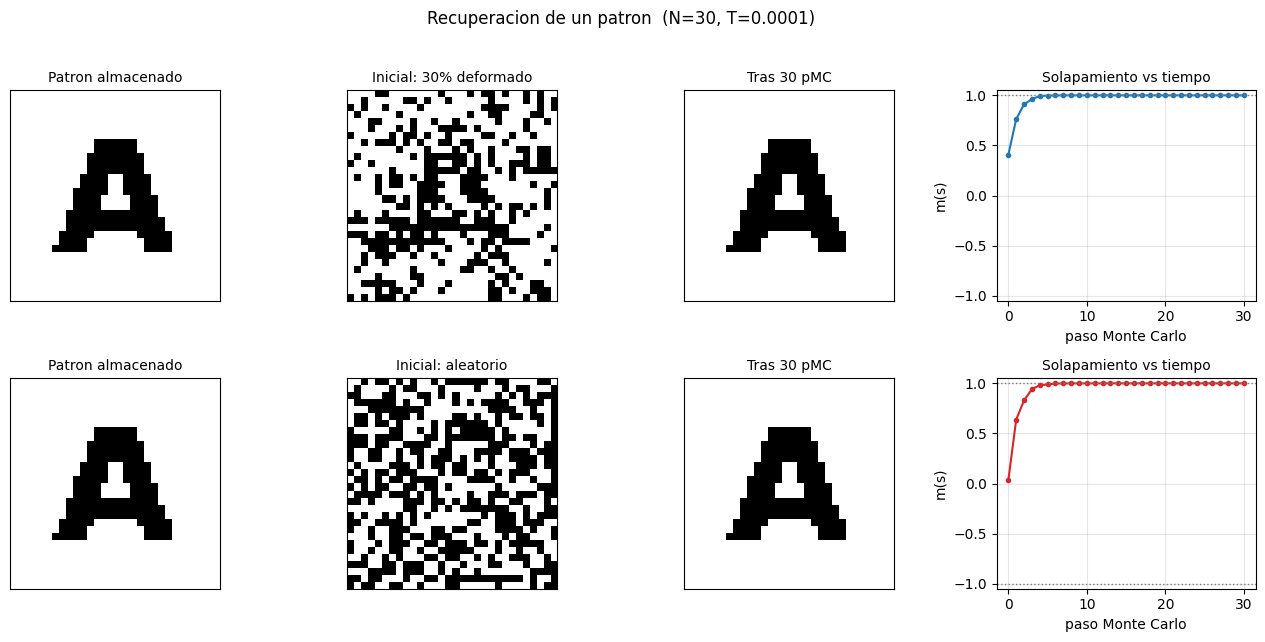

In [3]:
import tarea1_recuperacion as t1
t1.ejecutar();

La red recupera el patrón en muy pocos pasos Monte Carlo. Partiendo del patrón deformado al 30% (fila superior) el solapamiento parte de $\approx 0.4$ y sube a $+1$ en unos 5 pasos. Lo más llamativo es que incluso partiendo de **ruido completamente aleatorio** (fila inferior), con solapamiento inicial $\approx 0$, la red converge igualmente al patrón almacenado. Con un único patrón el paisaje de energía tiene esencialmente dos mínimos (el patrón y su antipatrón) y, a $T=10^{-4}$, la dinámica es prácticamente determinista: desciende directamente al mínimo más cercano. Esto ilustra la propiedad fundamental de la memoria asociativa.

### 3.2 Tarea 2 — Solapamiento frente a la temperatura

Con el mismo patrón se mide el solapamiento de equilibrio en función de $T$. Para cada temperatura se parte del patrón limpio (rama de recuperación), se deja equilibrar y se promedia el solapamiento sobre los últimos pasos, repitiendo sobre varias realizaciones para estimar el error.

T = 0.0050   <m> = +0.987 +/- 0.000
T = 0.0079   <m> = +0.930 +/- 0.001
T = 0.0108   <m> = +0.845 +/- 0.002
T = 0.0137   <m> = +0.772 +/- 0.002
T = 0.0166   <m> = +0.712 +/- 0.001
T = 0.0195   <m> = +0.652 +/- 0.002
T = 0.0224   <m> = +0.588 +/- 0.003
T = 0.0253   <m> = +0.520 +/- 0.005
T = 0.0282   <m> = +0.421 +/- 0.009
T = 0.0311   <m> = -0.019 +/- 0.080
T = 0.0339   <m> = -0.014 +/- 0.040
T = 0.0368   <m> = +0.000 +/- 0.014
T = 0.0397   <m> = -0.004 +/- 0.005
T = 0.0426   <m> = +0.015 +/- 0.011
T = 0.0455   <m> = -0.003 +/- 0.012
T = 0.0484   <m> = +0.008 +/- 0.008
T = 0.0513   <m> = +0.002 +/- 0.006
T = 0.0542   <m> = +0.004 +/- 0.009
T = 0.0571   <m> = -0.002 +/- 0.005
T = 0.0600   <m> = -0.011 +/- 0.005

Temperatura critica aproximada (maxima pendiente): T_c ~ 0.028


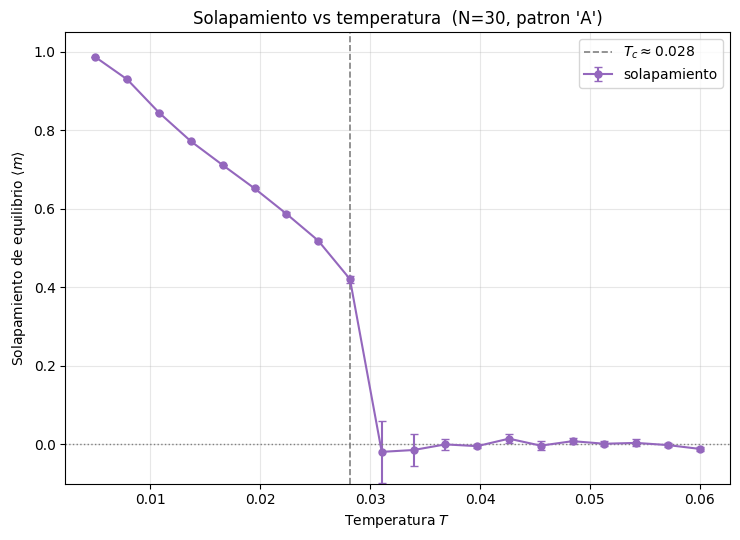

In [4]:
import tarea2_temperatura as t2
t2.ejecutar();

La curva reproduce una **transición de fase** análoga a la magnetización del modelo de Ising. A baja temperatura el solapamiento es $\approx 1$ (fase de **recuperación**: el patrón es estable frente a las fluctuaciones térmicas); al aumentar $T$ decrece y, superada una **temperatura crítica** $T_c$, cae bruscamente a $\approx 0$ (fase de **olvido**). La estimación por máxima pendiente da $T_c\approx 0.03$.

Conviene precisar la escala de temperatura. Con la codificación $0/1$ y la normalización $1/N^2$ de los pesos, $T_c$ **no** coincide con el valor clásico $T_c=1$ del Hopfield de espines $\pm1$; además, al ser un dígito o letra un patrón **disperso** ($a\approx0.16$), las barreras de energía de las neuronas en reposo son pequeñas ($\sim a^2$) y se desestabilizan a temperatura baja, de modo que $T_c$ resulta pequeña. La fenomenología —la existencia de una transición entre recuperación y olvido— es, no obstante, idéntica a la del Ising.

### 3.3 Tarea 3 — Varios patrones almacenados

Se almacenan ahora cuatro patrones a la vez (símbolos geométricos) y se observa la recuperación partiendo de **(i)** uno de ellos deformado al 25% y **(ii)** ruido aleatorio, midiendo el solapamiento con **todos** los patrones.

Solapamiento final (inicio = patron deformado): ['+1.00', '-0.19', '+0.04', '-0.01']
Solapamiento final (inicio aleatorio):         ['+0.01', '+0.04', '+0.06', '-1.00']


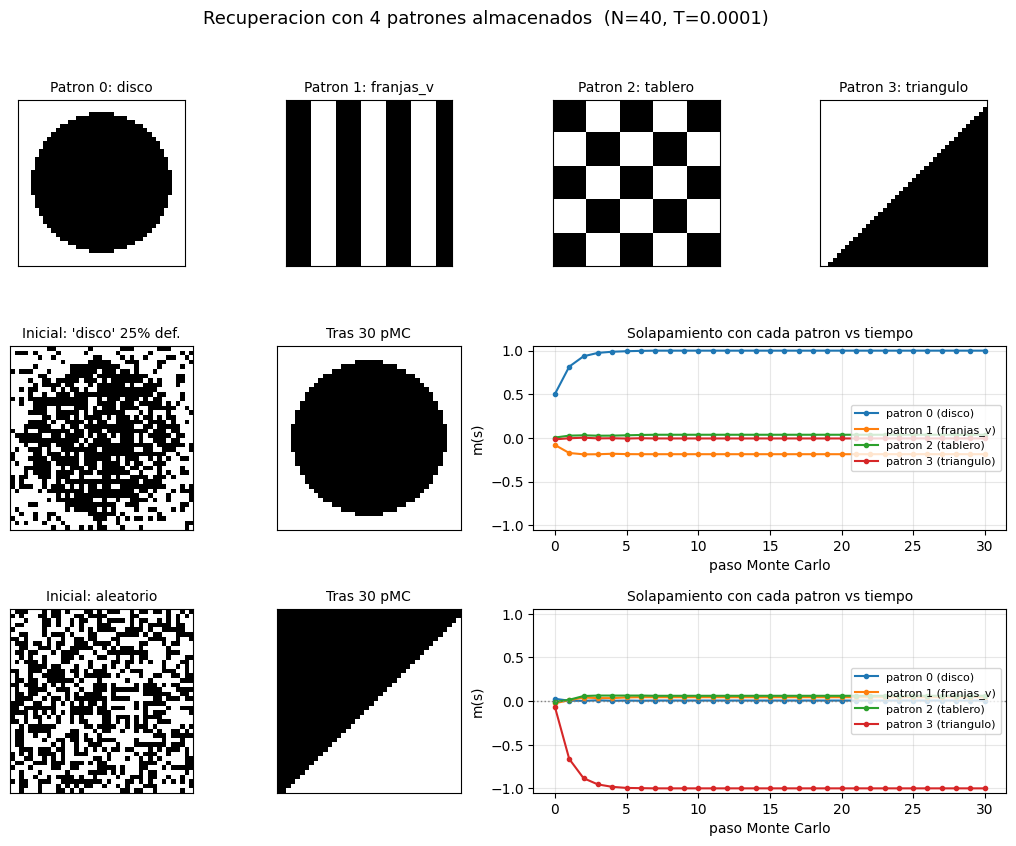

In [5]:
import tarea3_varios_patrones as t3
t3.ejecutar();

Con varios patrones la red sigue funcionando como memoria asociativa: partiendo del disco deformado al 25% (fila central) recupera limpiamente el disco —el solapamiento con ese patrón tiende a $+1$ y con los demás a $\approx 0$—. Partiendo de ruido aleatorio (fila inferior) la red cae en este caso en el **antipatrón** del triángulo (solapamiento $-1$, el triángulo invertido): es uno de los **estados espurios** mencionados en el enunciado, mínimos válidos del hamiltoniano tan legítimos como los propios patrones.

Una observación importante sobre la elección de patrones: la regla de Hebb solo almacena correctamente patrones **aproximadamente ortogonales y balanceados** ($a\approx0.5$). Por eso aquí se usan *símbolos* geométricos distintos entre sí y no dígitos o letras. Estos últimos son dispersos y están fuertemente correlacionados (toda la tinta se concentra en la región central, con correlaciones cruzadas de $0.5$–$0.8$), de modo que al almacenar varios a la vez la red no los distingue y colapsa a un estado mezcla con solapamiento alto con todos ellos. Es una limitación bien conocida de la regla de Hebb básica.

### 3.4 Tarea 4 — Capacidad de almacenamiento

Con patrones aleatorios (balanceados) y $T=10^{-4}$ se estudia cómo decae la recuperación al aumentar el número de patrones $P$ en una red de $N=20$ ($400$ neuronas). Un patrón «se recuerda» si su solapamiento final supera $0.75$; la fracción de patrones recordados se promedia sobre varias realizaciones independientes.

P =   4  alpha = 0.010   fraccion recordada = 1.000 +/- 0.000
P =   8  alpha = 0.020   fraccion recordada = 1.000 +/- 0.000
P =  12  alpha = 0.030   fraccion recordada = 1.000 +/- 0.000
P =  16  alpha = 0.040   fraccion recordada = 1.000 +/- 0.000
P =  20  alpha = 0.050   fraccion recordada = 1.000 +/- 0.000
P =  24  alpha = 0.060   fraccion recordada = 1.000 +/- 0.000
P =  28  alpha = 0.070   fraccion recordada = 1.000 +/- 0.000
P =  32  alpha = 0.080   fraccion recordada = 1.000 +/- 0.000
P =  36  alpha = 0.090   fraccion recordada = 1.000 +/- 0.000
P =  40  alpha = 0.100   fraccion recordada = 1.000 +/- 0.000
P =  44  alpha = 0.110   fraccion recordada = 0.992 +/- 0.006
P =  48  alpha = 0.120   fraccion recordada = 0.988 +/- 0.006
P =  52  alpha = 0.130   fraccion recordada = 0.966 +/- 0.011
P =  56  alpha = 0.140   fraccion recordada = 0.933 +/- 0.012
P =  60  alpha = 0.150   fraccion recordada = 0.881 +/- 0.018
P =  64  alpha = 0.160   fraccion recordada = 0.749 +/- 0.028
P =  68 

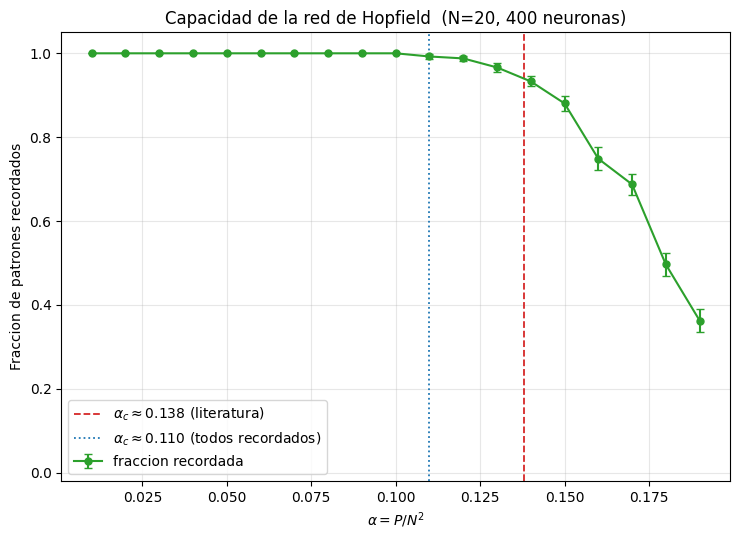

In [6]:
import tarea4_capacidad as t4
t4.ejecutar();

La fracción de patrones recordados se mantiene en $1$ hasta $\alpha\approx0.10$ y a partir de ahí decae, con una caída pronunciada centrada justo en el valor crítico clásico $\alpha_c\approx0.138$ obtenido analíticamente por Amit, Gutfreund y Sompolinsky para patrones aleatorios. El acuerdo con la literatura es muy bueno, teniendo en cuenta el tamaño finito de la red ($400$ neuronas) y que el criterio de recuerdo ($m>0.75$) es relativamente exigente.

La capacidad para que **todos** los patrones se recuerden sin error, $\alpha_c=P_c/N^2\approx0.11$ ($P_c\approx44$), es algo inferior a $0.138$ porque exige que *cada uno* de los patrones sea estable, criterio más estricto que la mera existencia de estados de recuperación. Por encima de $\alpha_c\approx0.138$ la red entra en una fase de *vidrio de espín* en la que los patrones dejan de ser atractores y la memoria se pierde.

## 4. Conclusiones

Se ha implementado y simulado una red neuronal de Hopfield mediante el algoritmo de Metropolis, reutilizando la maquinaria Monte Carlo del modelo de Ising. Expresando $\Delta H$ a través de las proyecciones sobre los patrones se ha conseguido una dinámica eficiente ($\mathcal{O}(N^2P)$ por paso) que evita almacenar la matriz de pesos completa, validada frente al cálculo directo.

Los resultados reproducen toda la fenomenología característica del modelo:

- La red **recupera patrones almacenados** a partir de entradas corruptas o ruidosas (memoria asociativa).
- Existe una **transición de fase** recuperación–olvido en temperatura, análoga a la del Ising.
- Con varios patrones la recuperación sigue funcionando, apareciendo además **estados espurios** (antipatrones), y se evidencia la necesidad de patrones balanceados y poco correlacionados.
- La **capacidad** de almacenamiento medida, $\alpha_c\approx0.11$–$0.14$, concuerda con el valor clásico $\alpha_c\approx0.138$ de la literatura.